Классификация ирисов (Iris)

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from nn_framework import *

iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

train_ds = Dataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=16)
test_loader = DataLoader(Dataset(X_test, y_test), batch_size=16, shuffle=False)

model_net = Sequential(
    Linear(4, 16),
    ReLU(),
    Linear(16, 3),
    Softmax()
)

model = Model(
    network=model_net,
    loss_fn=CrossEntropy(),
    optimizer=Adam(model_net.parameters(), lr=0.01),
    metrics=[Accuracy()]
)

print("Обучение на Iris: ")
model.fit(train_loader, epochs=25)

print("\nРезультаты на тестовой выборке:")
results = model.evaluate(test_loader)
print(results)

Обучение на Iris: 
Epoch [1/25] - loss: 0.8531 - accuracy: 0.7333 - 0.01s
Epoch [2/25] - loss: 0.5570 - accuracy: 0.8083 - 0.00s
Epoch [3/25] - loss: 0.4331 - accuracy: 0.8500 - 0.00s
Epoch [4/25] - loss: 0.3499 - accuracy: 0.8500 - 0.00s
Epoch [5/25] - loss: 0.2993 - accuracy: 0.8583 - 0.00s
Epoch [6/25] - loss: 0.2957 - accuracy: 0.9083 - 0.00s
Epoch [7/25] - loss: 0.2579 - accuracy: 0.9167 - 0.00s
Epoch [8/25] - loss: 0.2351 - accuracy: 0.9333 - 0.00s
Epoch [9/25] - loss: 0.2204 - accuracy: 0.9417 - 0.00s
Epoch [10/25] - loss: 0.2244 - accuracy: 0.9500 - 0.00s
Epoch [11/25] - loss: 0.1850 - accuracy: 0.9583 - 0.00s
Epoch [12/25] - loss: 0.1725 - accuracy: 0.9583 - 0.00s
Epoch [13/25] - loss: 0.1575 - accuracy: 0.9667 - 0.00s
Epoch [14/25] - loss: 0.1444 - accuracy: 0.9667 - 0.00s
Epoch [15/25] - loss: 0.1352 - accuracy: 0.9583 - 0.00s
Epoch [16/25] - loss: 0.1279 - accuracy: 0.9583 - 0.00s
Epoch [17/25] - loss: 0.1171 - accuracy: 0.9583 - 0.00s
Epoch [18/25] - loss: 0.1153 - accurac

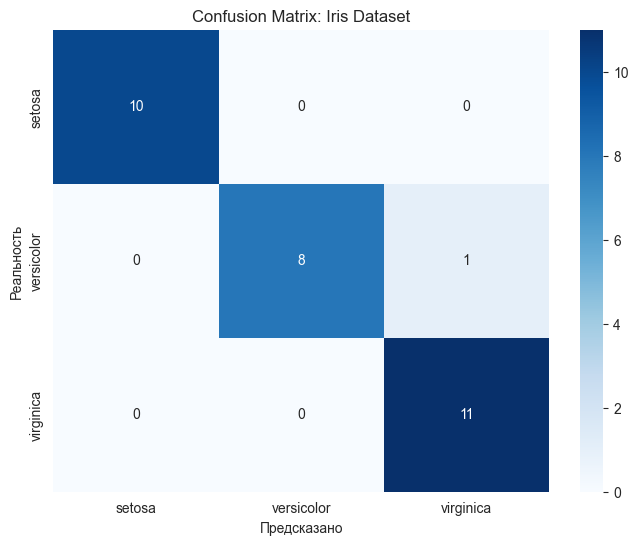

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_test = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix: Iris Dataset')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

Распознавание цифр (MNIST)

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data[:2000] / 255.0
y = mnist.target[:2000].astype(int).reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(X, y_onehot, test_size=0.2)

train_loader = DataLoader(Dataset(X_train_mnist, y_train_mnist), batch_size=32)
test_loader = DataLoader(Dataset(X_test_mnist, y_test_mnist), batch_size=32, shuffle=False)

mnist_net = Sequential(
    Linear(784, 64),
    ReLU(),
    Linear(64, 10),
    Softmax()
)

mnist_model = Model(
    network=mnist_net,
    loss_fn=CrossEntropy(),
    optimizer=Adam(mnist_net.parameters(), lr=0.005),
    metrics=[Accuracy()]
)

print("Обучение на MNIST (2000 прим.):")
mnist_model.fit(train_loader, epochs=10)

idx = np.random.randint(len(X_test_mnist))
sample = X_test_mnist[idx:idx+1]
pred = mnist_model.predict(sample)
print(f"\nТест: Реальная цифра {np.argmax(y_test_mnist[idx])}, Предсказано {np.argmax(pred)}")

Обучение на MNIST (2000 прим.):
Epoch [1/10] - loss: 0.8840 - accuracy: 0.9044 - 0.26s
Epoch [2/10] - loss: 0.3062 - accuracy: 0.9487 - 0.26s
Epoch [3/10] - loss: 0.2229 - accuracy: 0.9600 - 0.25s
Epoch [4/10] - loss: 0.1648 - accuracy: 0.9850 - 0.31s
Epoch [5/10] - loss: 0.0991 - accuracy: 0.9725 - 0.27s
Epoch [6/10] - loss: 0.0753 - accuracy: 0.9756 - 0.28s
Epoch [7/10] - loss: 0.0521 - accuracy: 0.9969 - 0.27s
Epoch [8/10] - loss: 0.0314 - accuracy: 0.9994 - 0.30s
Epoch [9/10] - loss: 0.0223 - accuracy: 1.0000 - 0.36s
Epoch [10/10] - loss: 0.0117 - accuracy: 1.0000 - 0.30s

Тест: Реальная цифра 6, Предсказано 6


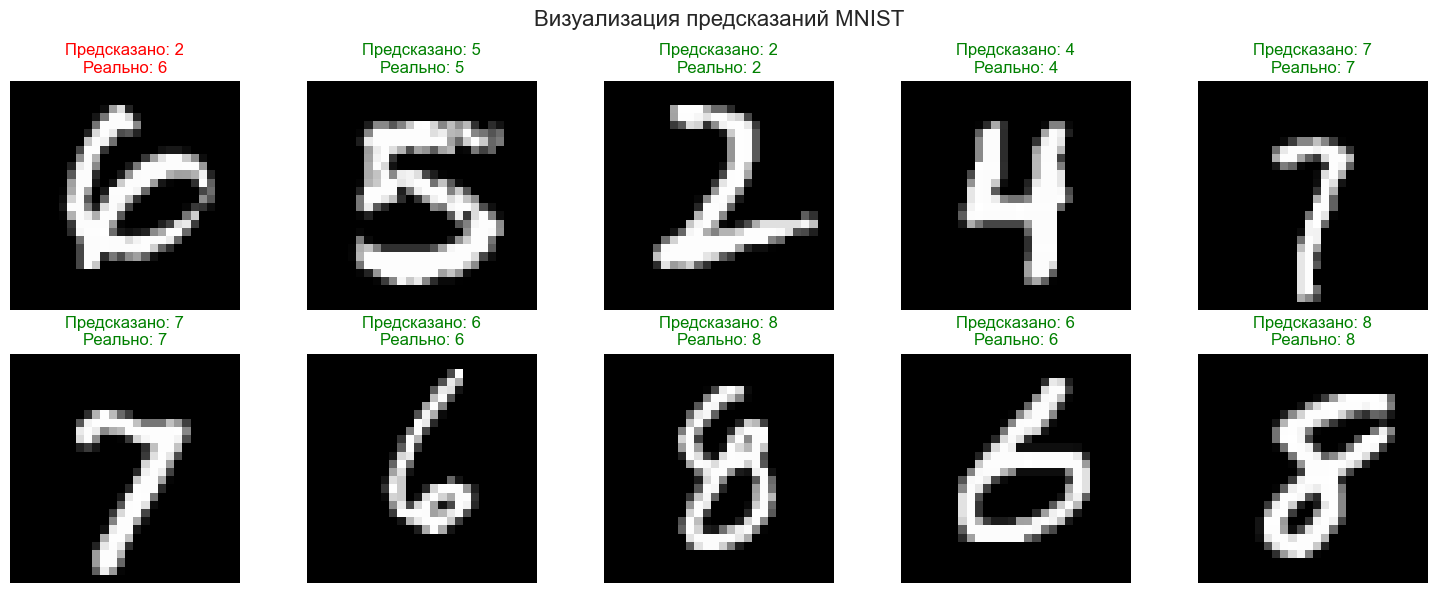

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.suptitle("Визуализация предсказаний MNIST", fontsize=16)

indices = np.random.choice(len(X_test_mnist), 10, replace=False)

for i, idx in enumerate(indices):
    img = X_test_mnist[idx].reshape(28, 28)

    probs = mnist_model.predict(X_test_mnist[idx:idx+1])
    pred = np.argmax(probs)
    true = np.argmax(y_test_mnist[idx])

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')

    color = 'green' if pred == true else 'red'
    plt.title(f"Предсказано: {pred}\nРеально: {true}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

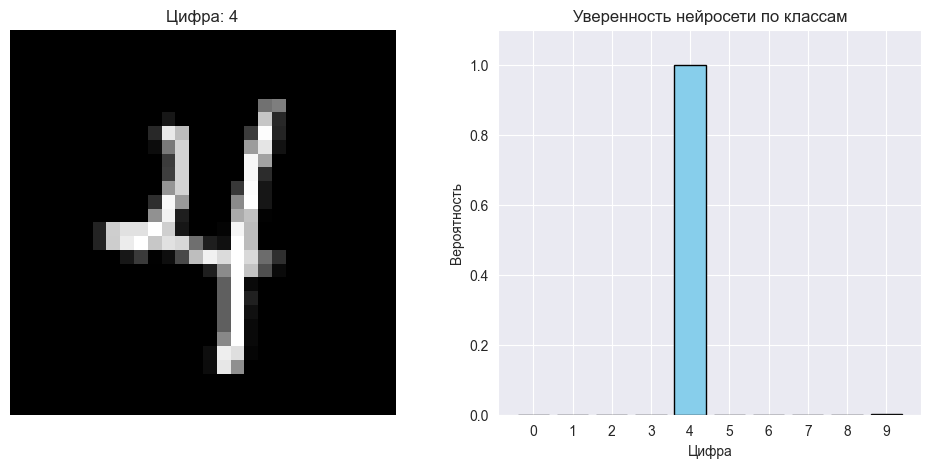

In [5]:
random_idx = np.random.randint(len(X_test_mnist))
sample_img = X_test_mnist[random_idx:random_idx + 1]
probabilities = mnist_model.predict(sample_img)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(sample_img.reshape(28, 28), cmap='gray')
ax1.set_title(f"Цифра: {np.argmax(y_test_mnist[random_idx])}")
ax1.axis('off')

ax2.bar(range(10), probabilities, color='skyblue', edgecolor='black')
ax2.set_xticks(range(10))
ax2.set_ylim(0, 1.1)
ax2.set_title("Уверенность нейросети по классам")
ax2.set_xlabel("Цифра")
ax2.set_ylabel("Вероятность")

plt.show()